# To simulate a real time training for an ARMA model 

In [20]:
import pandas as pd 
import os 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

We implement a class to test ARMA models against the other models 

In [21]:
class ARMA_model():
    def __init__(self, time_series: pd.Series, order: tuple, horizon: int, split_location: int, train_start=0):
        self.data = time_series
        self.order = order
        self.horizon = horizon
        self.split_location = split_location
        self.train_start = train_start
        self.T = len(self.data)
        self.y_true = self.data[self.split_location:]

    def predict(self):
        y_pred = []
        j = self.split_location
        current_start = self.train_start
        while j < self.T:
            steps_to_forecast = min(self.horizon, self.T - j)
            data_to_train = self.data[current_start:j]
            try:
                model = SARIMAX(
                    endog=data_to_train,
                    order=(self.order[0], 0, self.order[1]),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False, maxiter=50)
                predictions = model.forecast(steps=steps_to_forecast)
            except (np.linalg.LinAlgError, ValueError, np.linalg.LinAlgError, Exception) as e:
                last_val = data_to_train.iloc[-1] # Naive
                predictions = np.full(steps_to_forecast, last_val)
            y_pred.extend(predictions)
            j += steps_to_forecast
            current_start += steps_to_forecast
        self.y_pred = np.array(y_pred[:len(self.y_true)])
        return self.y_pred

    def measure_performance(self, minutes_list):
        metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]
        metric_names = ['MSE', 'MAE', 'MAPE']
        array_results = np.zeros(shape=(len(metric_names), len(minutes_list)))

        results = {m: ([], []) for m in minutes_list}  # (y_true, y_pred)

        j = self.split_location
        while j < self.T:
            horizon_available = min(self.horizon, self.T - j)
            for m in minutes_list:
                if m <= horizon_available:
                    idx = j - self.split_location + m - 1
                    if idx < len(self.y_true):
                        y_true_m = self.y_true.iloc[idx]
                        y_pred_m = self.y_pred[idx]
                        results[m][0].append(y_true_m)
                        results[m][1].append(y_pred_m)
            j += horizon_available

        for i, metric in enumerate(metrics):
            for j, m in enumerate(minutes_list):
                y_t, y_p = results[m]
                if len(y_t) > 0:
                    array_results[i, j] = metric(y_t, y_p)
                else:
                    array_results[i, j] = np.nan

        return pd.DataFrame(data=array_results, index=metric_names, columns=minutes_list)


In [22]:
class Patients_ARMA():
    def __init__(self, cut_point:int, horizon:int, folds:int, orders: dict):
        self.cut_point = cut_point
        self.horizon = horizon
        self.folds = folds
        self.orders = orders
    

        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        spliter = TimeSeriesSplit(n_splits=self.folds, test_size=288) ## We test using one day
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            patients[key] = []
            series = pd.read_csv(fp, sep=';')[:self.cut_point]['glucose']
            for k_fold in spliter.split(series):
                split_location = k_fold[0][-1]
                end_fold = k_fold[1][-1]
                sub_series = series[:end_fold]
                patients[key].append((split_location, sub_series))
        return patients
        
    
    def evaluate_all_patients(self):
        keys = list(self.patients.keys())
        matrix_set_all_patients = []
        for key in keys:
            print(key)
            folds_patient = self.patients[key]
            matrix_set_patient = []
            for split_location, fold_data in folds_patient:
                order = self.orders[key]
                arma_model = ARMA_model(time_series=fold_data, order=(order[0], 1, order[1]), horizon=self.horizon, split_location=split_location)
                _= arma_model.predict()
                results_fold = arma_model.measure_performance(minutes_list=range(1, self.horizon+1))
                matrix_set_patient.append(results_fold.values)
            final_results_patient = np.stack(arrays=matrix_set_patient, axis=0).mean(axis=0)  # (FOLDS, METRICS, HORIZONS) before mean
            #print(pd.DataFrame(final_results_patient, index=['MSE', 'MAE', 'MAPE'], columns=range(1, self.horizon+1)))
            matrix_set_all_patients.append(final_results_patient)
        results = np.stack(matrix_set_all_patients, axis=0)
        self.results = results
        return results
    
    def visualize_selected_horizons(self, figsize=(15, 5)):
        horizon_indices = [0, 2, 5, 11]
        target_minutes = [5, 15, 30, 60]

        selected_data = self.results[:, :, horizon_indices]

        metric_names = ['MSE', 'MAE', 'MAPE']
        colors = ['steelblue', 'seagreen', 'tomato']
        minute_labels = [f"{m} min" for m in target_minutes]

        
        _, axes = plt.subplots(1, 3, figsize=figsize)

        for ax, metric_idx, metric, color in zip(axes, range(3), metric_names, colors):
            data_metric = selected_data[:, metric_idx, :]  # (n_patients, 3)

            # Preparar datos para seaborn
            long_data = []
            for p in range(data_metric.shape[0]):
                for i, label in enumerate(minute_labels[:-1]):
                    long_data.append({
                        'Horizonte': label,
                        'Valor': data_metric[p, i]
                    })
            df_long = pd.DataFrame(long_data)

            # Asegurar el orden de las categorías
            df_long['Horizonte'] = pd.Categorical(
                df_long['Horizonte'],
                categories=minute_labels,
                ordered=True
            )

            sns.boxplot(
                data=df_long,
                x='Horizonte',
                y='Valor',
                ax=ax,
                color=color,
                width=0.6
            )
            ax.set_title(f'{metric.upper()}', fontsize=14)
            ax.set_xlabel('Horizonte de predicción')
            ax.set_ylabel(metric.upper())
            ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        
        print("\nSummary by horizon")
        for metric_idx, metric in enumerate(metric_names):
            data_metric = selected_data[:, metric_idx, :]
            df_summary = pd.DataFrame(data_metric, columns=minute_labels)
            print(f'{metric.upper()}')
            print(df_summary)
            print(df_summary.describe())
            print('*'*50)



In [23]:
orders = {
    'HUPA0004P': (4, 3),
    'HUPA0006P': (4, 4),
    'HUPA0007P': (1, 3),
    'HUPA0009P': (3, 4),
    'HUPA0005P': (4, 2),
    'HUPA0011P': (3, 3),
    'HUPA0003P': (3, 3),
    'HUPA0001P': (4, 3),
    'HUPA0010P': (4, 4),
    'HUPA0002P': (4, 3),
    'HUPA0014P': (4, 4),
    'HUPA0015P': (4, 4),
    'HUPA0016P': (4, 3),
    'HUPA0017P': (4, 3),
    'HUPA0018P': (4, 4),
    'HUPA0021P': (4, 3),
    'HUPA0020P': (4, 4),
    'HUPA0024P': (3, 2),
    'HUPA0019P': (4, 4),
    'HUPA0023P': (4, 4),
    'HUPA0022P': (1, 3),
    'HUPA0025P': (4, 3),
    'HUPA0028P': (4, 4),
    'HUPA0026P': (4, 3),
    'HUPA0027P': (4, 3)
    }

In [24]:
horizon_6 = Patients_ARMA(cut_point=2290, horizon=12, folds=5, orders=orders)

In [25]:
results = horizon_6.evaluate_all_patients()

HUPA0004P


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/

HUPA0006P


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/

HUPA0007P


...

/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/

HUPA0026P


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/

HUPA0027P


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/

In [26]:
results.shape

(25, 3, 12)

In [27]:
horizon_6.results.shape

(25, 3, 12)

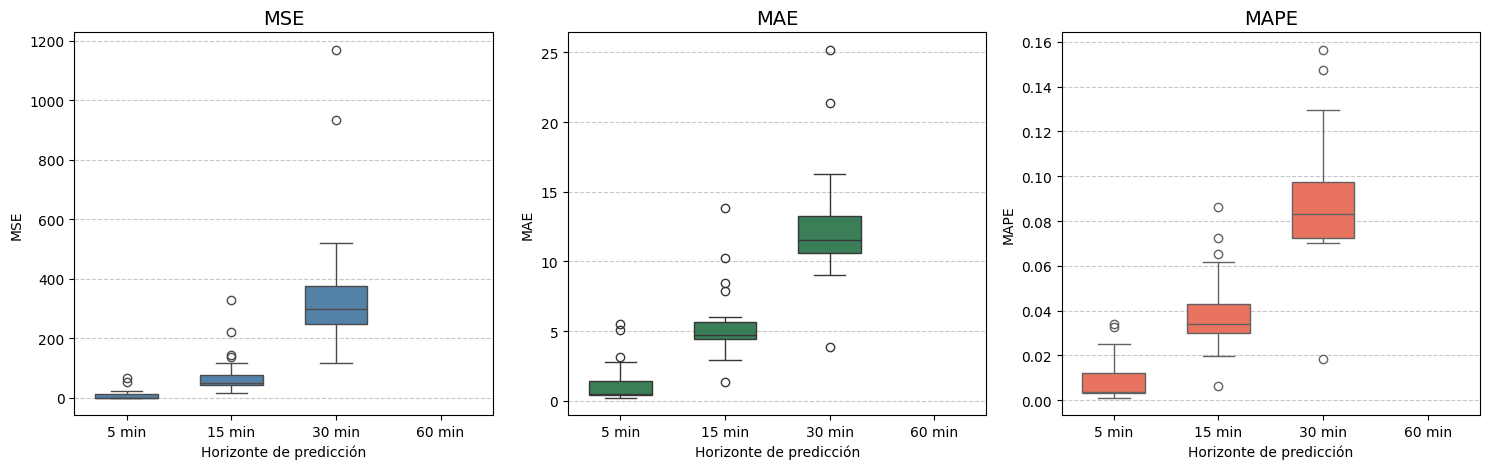


Summary by horizon
MSE
        5 min      15 min       30 min       60 min
0    0.354075   56.097969   332.567814  1450.543858
1    0.414898   40.643669   261.426702  1447.875499
2   53.152338  328.120770  1169.422729  3505.236275
3    0.237414   20.131910   117.071144   470.849197
4   24.168547  136.722531   375.400316  1102.341877
5    2.426055   57.767088   492.021858  1950.724764
6   11.800010   78.003553   264.538430  1198.722719
7   66.866960  221.025584   934.687144  3045.229543
8   14.620266  116.485541   517.604857  1380.371747
9    0.368076   32.993251   190.390376   754.516133
10   0.439817   38.260891   298.377523  1437.897070
11   0.448516   49.055452   375.616624  1839.068766
12   0.500410   47.911145   371.234394  1378.855872
13   0.352464   67.142671   317.395564  1057.576333
14   0.510438   42.244060   247.700272  1287.402427
15   0.425682   16.036834   205.670295  1092.788647
16   0.391847   44.190362   301.593494  1392.325147
17   0.292796   51.939900   250.685097  

In [28]:
horizon_6.visualize_selected_horizons()